# 04 - ffNN regularizada

Modelo feed-forward mas completo que el `03_ffNN_normalizada`: mantiene la normalizacion, pero anade BatchNorm, Dropout y regularizacion L2. Ademas, en esta version las imagenes de train/valid se cargan una sola vez en RAM para evitar abrir `.tif` en cada batch.


## Librerias y configuracion


In [1]:
import json
import math
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import rasterio
import warnings
from rasterio.errors import NotGeoreferencedWarning

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


2026-05-28 17:01:13.382561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779987673.579897      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779987673.639493      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779987674.120698      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779987674.120745      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779987674.120748      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Kaggle-only: busca automaticamente xview_ann_train.json dentro de /kaggle/input.
KAGGLE_INPUT_DIR = Path('/kaggle/input')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError(
        'No existe /kaggle/input. Ejecuta este notebook en Kaggle y anade el dataset xview_recognition como Input.'
    )

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json dentro de /kaggle/input. '
        f'Inputs disponibles: {available_inputs}. '
        'Comprueba que has anadido el dataset xview_recognition al notebook.'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working')

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition
ANN_JSON: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


## Datos


### Lectura del JSON


In [3]:
def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
    with rasterio.open(DATA_ROOT / filename, 'r') as src_raster:
        img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=src_raster.profile['dtype'])
        for band in range(src_raster.count):
            img[:, :, band] = src_raster.read(band + 1)
    return img


In [4]:
with open(ANN_JSON, 'r', encoding='utf-8') as f:
    json_data = json.load(f)

categories = {
    int(k): v['name']
    for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))
}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}
num_classes = len(category_names)

print('Categorias:')
print(categories)
print('Imagenes en JSON:', len(json_data['images']))
print('Anotaciones en JSON:', len(json_data['annotations']))


Categorias:
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Imagenes en JSON: 18746
Anotaciones en JSON: 18746


In [5]:
rows = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    rows.append({
        'image_id': json_img['image_id'],
        'filename': json_img['filename'],
        'width': json_img['width'],
        'height': json_img['height'],
        'category': json_ann['category_id'],
        'label': category_to_idx[json_ann['category_id']],
        'bbox': json_ann['bbox'],
        'exists': (DATA_ROOT / json_img['filename']).exists(),
    })

df = pd.DataFrame(rows)
print('Total train:', len(df))
print('Archivos encontrados:', int(df['exists'].sum()))
df.head()


Total train: 18746
Archivos encontrados: 18746


,image_id,filename,width,height,category,label,bbox,exists
0,0234476c-a017-4c9b-bd2f-872193076cca.tif,xview_train/Building/0234476c-a017-4c9b-bd2f-8...,224,224,Building,8,"[0, 0, 224, 224]",True
1,f2543073-9933-44c4-98e0-15eee2dffe2a.tif,xview_train/Building/f2543073-9933-44c4-98e0-1...,224,224,Building,8,"[0, 0, 224, 224]",True
2,6df5b6a5-82b0-4abb-8deb-7d7154c977bc.tif,xview_train/Building/6df5b6a5-82b0-4abb-8deb-7...,224,224,Building,8,"[0, 0, 224, 224]",True
3,ddbd2636-ce3c-4406-a5cf-92fa557dbd3c.tif,xview_train/Building/ddbd2636-ce3c-4406-a5cf-9...,224,224,Building,8,"[0, 0, 224, 224]",True
4,609064d1-3719-4163-ad36-577dab9805f0.tif,xview_train/Building/609064d1-3719-4163-ad36-5...,224,224,Building,8,"[0, 0, 224, 224]",True


Distribucion por clase:
category
Cargo plane            635
Small car             3324
Bus                   1768
Truck                 2210
Motorboat             1069
Fishing vessel         706
Dump truck            1236
Excavator              789
Building              3594
Helipad                111
Storage tank          1469
Shipping container    1523
Pylon                  312
Name: count, dtype: int64


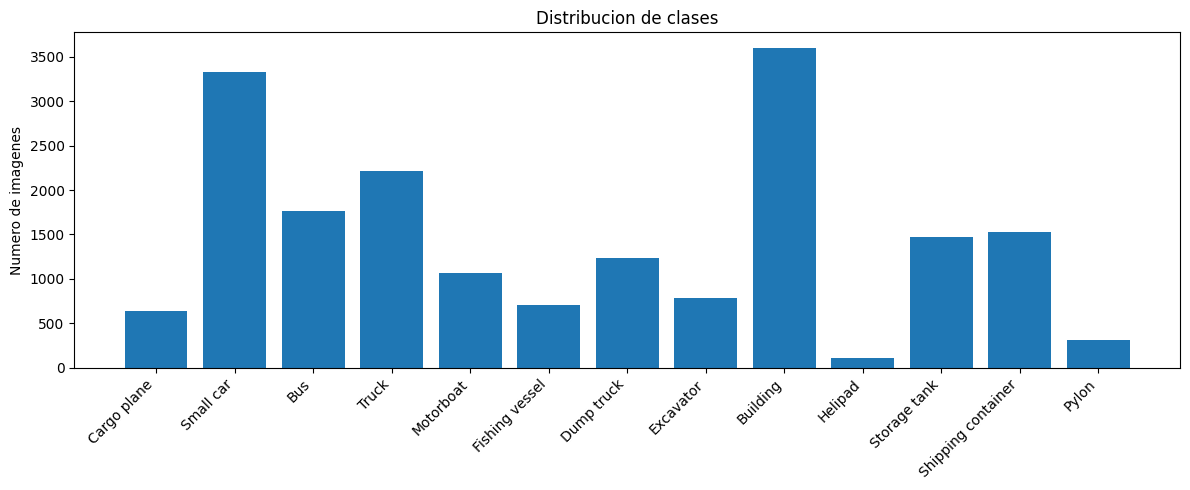

In [6]:
class_counts = df['category'].value_counts().reindex(category_names)
print('Distribucion por clase:')
print(class_counts)

plt.figure(figsize=(12, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de clases')
plt.tight_layout()
plt.show()


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype original: uint8
Min / Max original: 0 86
Etiqueta: Building
Indice de clase: 8
Bounding box: [0, 0, 224, 224]

Primeros pixeles del array original:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]

Primeros pixeles normalizados:
[[[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.18039216 0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]]


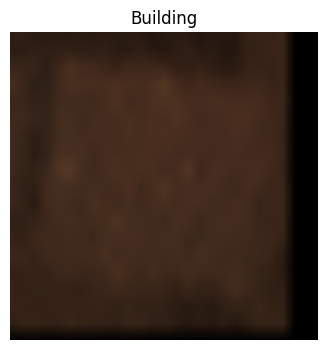

In [7]:
sample_row = df.iloc[0]
sample_img = load_geoimage(sample_row['filename'])
sample_img_norm = sample_img.astype(np.float32) / 255.0

print('Filename:', sample_row['filename'])
print('Shape:', sample_img.shape)
print('Dtype original:', sample_img.dtype)
print('Min / Max original:', sample_img.min(), sample_img.max())
print('Etiqueta:', sample_row['category'])
print('Indice de clase:', sample_row['label'])
print('Bounding box:', sample_row['bbox'])
print('')
print('Primeros pixeles del array original:')
print(sample_img[:3, :3, :])
print('')
print('Primeros pixeles normalizados:')
print(sample_img_norm[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(sample_row['category'])
plt.axis('off')
plt.show()


### Split train/valid


In [8]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=df['label'],
)

print('Train:', len(train_df))
print('Validation:', len(val_df))

split_counts = pd.concat([
    train_df['category'].value_counts().reindex(category_names).rename('train'),
    val_df['category'].value_counts().reindex(category_names).rename('valid'),
], axis=1)
split_counts


Train: 15934
Validation: 2812


,train,valid
category,,
Cargo plane,540,95
Small car,2825,499
Bus,1503,265
Truck,1878,332
Motorboat,909,160
Fishing vessel,600,106
Dump truck,1051,185
Excavator,671,118
Building,3055,539


### Carga en memoria RAM

Cargamos train y valid una sola vez como `uint8`. La normalizacion se hace dentro del modelo con una capa `Rescaling(1./255)`, para evitar guardar todo el dataset como `float32` en memoria.


In [10]:
def dataframe_to_arrays(data):
    n = len(data)

    X = np.empty((n, 224, 224, 3), dtype=np.uint8)
    y_idx = np.empty((n,), dtype=np.int32)

    for i, (_, row) in enumerate(data.iterrows()):
        X[i] = load_geoimage(row['filename'])
        y_idx[i] = row['label']

        if (i + 1) % 1000 == 0:
            print(f'Cargadas {i + 1}/{n} imagenes')

    y = tf.keras.utils.to_categorical(y_idx, num_classes=num_classes).astype(np.float32)

    return X, y, y_idx

X_train, y_train, y_train_idx = dataframe_to_arrays(train_df)
X_valid, y_valid, y_valid_idx = dataframe_to_arrays(val_df)

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)

Cargadas 1000/15934 imagenes
Cargadas 2000/15934 imagenes
Cargadas 3000/15934 imagenes
Cargadas 4000/15934 imagenes
Cargadas 5000/15934 imagenes
Cargadas 6000/15934 imagenes
Cargadas 7000/15934 imagenes
Cargadas 8000/15934 imagenes
Cargadas 9000/15934 imagenes
Cargadas 10000/15934 imagenes
Cargadas 11000/15934 imagenes
Cargadas 12000/15934 imagenes
Cargadas 13000/15934 imagenes
Cargadas 14000/15934 imagenes
Cargadas 15000/15934 imagenes
Cargadas 1000/2812 imagenes
Cargadas 2000/2812 imagenes
X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32


## Red


### Arquitectura y summary


In [11]:
BATCH_SIZE = 64
EPOCHS = 50
L2 = 1e-4

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1.0 / 255.0),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(L2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(L2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(L2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


I0000 00:00:1779988491.926841      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779988491.932777      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   154,140,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,805,773 (590.54 MB)

 Trainable params: 154,802,701 (590.53 MB)

 Non-trainable params: 3,072 (12.00 KB)

### Callbacks


In [12]:
MODEL_PATH = WORKDIR / '04_ffnn_regularizada.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_PATH), monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/04_ffnn_regularizada.keras


### Entrenamiento


In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)


Epoch 1/50


I0000 00:00:1779988506.257216     135 service.cc:152] XLA service 0x7879f000e9c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779988506.257273     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779988506.257281     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779988506.826723     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/249 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.0694 - loss: 3.4245

I0000 00:00:1779988511.538164     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2367 - loss: 2.6837
Epoch 1: val_accuracy improved from None to 0.36131, saving model to /kaggle/working/04_ffnn_regularizada.keras

Epoch 1: finished saving model to /kaggle/working/04_ffnn_regularizada.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step - accuracy: 0.2933 - loss: 2.4756 - val_accuracy: 0.3613 - val_loss: 2.2039 - learning_rate: 3.0000e-04
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3687 - loss: 2.1925
Epoch 2: val_accuracy improved from 0.36131 to 0.38834, saving model to /kaggle/working/04_ffnn_regularizada.keras

Epoch 2: finished saving model to /kaggle/working/04_ffnn_regularizada.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.3759 - loss: 2.1554 - val_accuracy: 0.3883 - val_loss: 2.1316 - learning_rate: 3.0000e-04
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3962 - loss: 2.0685
Epoch 3: val_accuracy did not improve from 0.38834
249/249 ━━━━━━━━━━━━━

## Resultados


### Graficas de entrenamiento


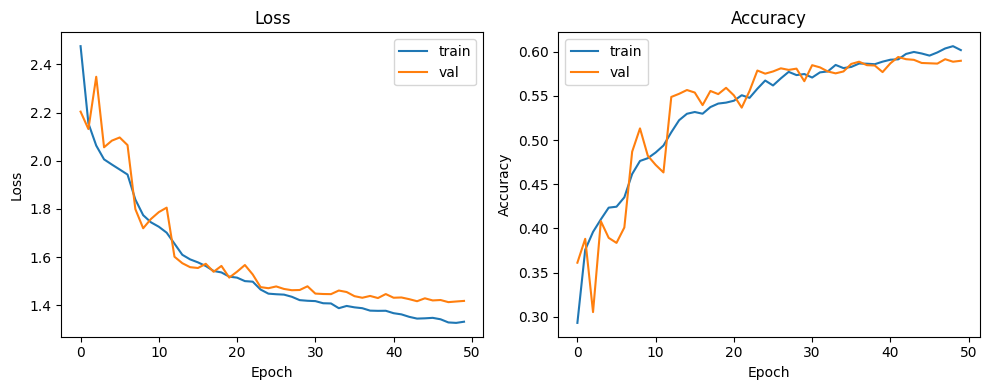

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Matriz de confusion


In [15]:
model.load_weights(MODEL_PATH)
probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx

cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


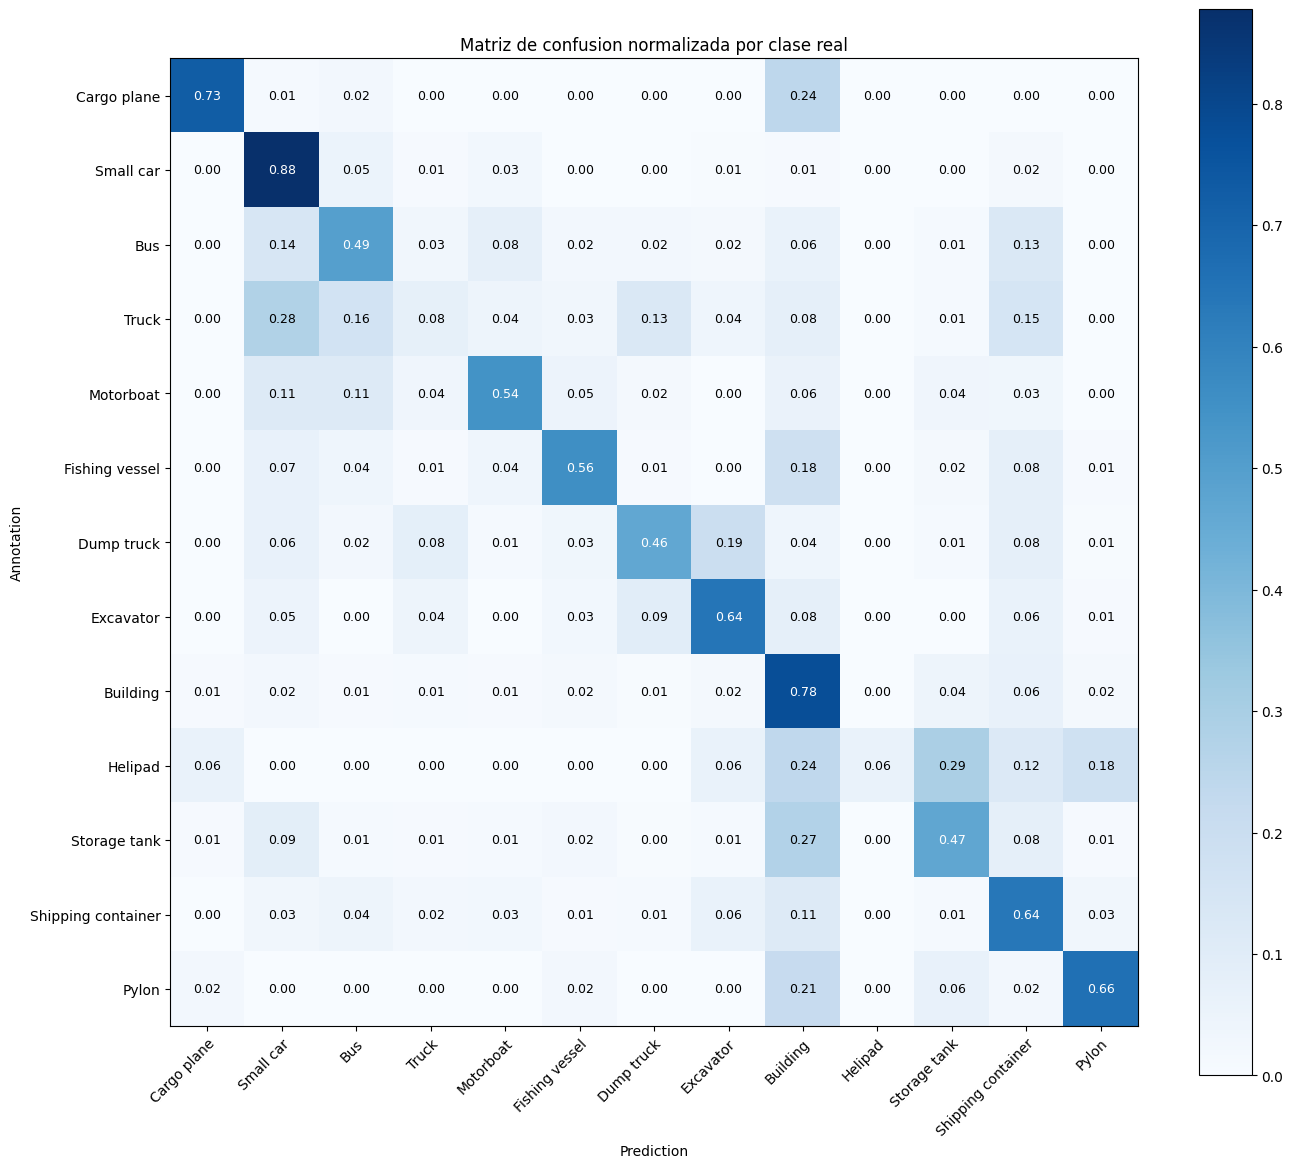

In [17]:
def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    ax.set_title('Matriz de confusion normalizada por clase real')
    fig.tight_layout()
    plt.show()

draw_confusion_matrix_percent(cm, category_names)


### Metricas por clase


In [18]:
correct = np.diag(cm).astype(float)
total_true = np.sum(cm, axis=1).astype(float)
total_pred = np.sum(cm, axis=0).astype(float)

print('Mean Accuracy: %.3f%%' % (np.sum(correct) / np.sum(total_true) * 100))
print('Mean Recall: %.3f%%' % ((correct / np.maximum(total_true, np.finfo(np.float64).eps)).mean() * 100))
print('Mean Precision: %.3f%%' % ((correct / np.maximum(total_pred, np.finfo(np.float64).eps)).mean() * 100))

for idx, name in enumerate(category_names):
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    recall = tp / np.maximum(tp + fn, np.finfo(np.float64).eps)
    precision = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)
    specificity = tn / np.maximum(tn + fp, np.finfo(np.float64).eps)
    f1_score = 2 * ((precision * recall) / np.maximum(precision + recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (name, recall * 100, precision * 100, specificity * 100, f1_score * 100))


Mean Accuracy: 59.388%
Mean Recall: 53.713%
Mean Precision: 60.158%
> Cargo plane: Recall: 72.632% Precision: 87.342% Specificity: 99.632% Dice: 79.310%
> Small car: Recall: 87.776% Precision: 67.488% Specificity: 90.878% Dice: 76.307%
> Bus: Recall: 49.434% Precision: 51.172% Specificity: 95.092% Dice: 50.288%
> Truck: Recall: 7.530% Precision: 32.468% Specificity: 97.903% Dice: 12.225%
> Motorboat: Recall: 54.375% Precision: 56.863% Specificity: 97.511% Dice: 55.591%
> Fishing vessel: Recall: 55.660% Precision: 53.636% Specificity: 98.115% Dice: 54.630%
> Dump truck: Recall: 46.486% Precision: 54.777% Specificity: 97.297% Dice: 50.292%
> Excavator: Recall: 64.407% Precision: 47.799% Specificity: 96.919% Dice: 54.874%
> Building: Recall: 77.551% Precision: 66.244% Specificity: 90.629% Dice: 71.453%
> Helipad: Recall: 5.882% Precision: 100.000% Specificity: 100.000% Dice: 11.111%
> Storage tank: Recall: 46.818% Precision: 66.026% Specificity: 97.955% Dice: 54.787%
> Shipping container:

## Codabench

El conjunto test no tiene etiquetas publicas. Esta seccion recorre `xview_test`, genera `prediction.json` y lo comprime como `submission.zip` para Codabench.


In [19]:
test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))

assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'


Number of testing images: 2365


In [20]:
model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]

    # Ruta para guardar en el JSON: relativa a xview_test.
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]

    # Ruta para leer con load_geoimage: relativa a DATA_ROOT.
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_geoimage(filename) for filename in load_filenames]).astype(np.uint8)
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_04.json'
submission_path = WORKDIR / 'submission_04.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_04.json - 708446 bytes
/kaggle/working/submission_04.zip - 162595 bytes


/kaggle/working/submission_04.zip